In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
GPU available: False


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/brain-tumor-segmentation"
)

OUTPUT_DIR = DRIVE_PROJECT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Results will be saved in:")
print(OUTPUT_DIR)

Results will be saved in:
/content/drive/MyDrive/brain-tumor-segmentation/outputs


In [4]:
!pip -q install --upgrade kagglehub

In [5]:
import kagglehub
from pathlib import Path
downloaded_path = Path(
    kagglehub.dataset_download(
        "briscdataset/brisc2025"
    )
)

print("Dataset downloaded to:")
print(downloaded_path)

100%|██████████| 250M/250M [00:03<00:00, 74.1MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6


In [6]:
import kagglehub

kagglehub.login()

In [7]:
downloaded_path = Path(
    kagglehub.dataset_download(
        "briscdataset/brisc2025"
    )
)

In [8]:
segmentation_folders = list(
    downloaded_path.rglob("segmentation_task")
)

print("Segmentation folders found:")
for folder in segmentation_folders:
  print(folder)

if not segmentation_folders:
  raise FileNotFoundError(
      "No segmentation_task folder was found."
  )

DATA_ROOT = segmentation_folders[0]

print("\nUsing data from:")
print(DATA_ROOT)



Segmentation folders found:
/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/segmentation_task

Using data from:
/root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025/segmentation_task


In [9]:
TRAIN_IMAGE_DIR = DATA_ROOT / "train" / "images"
TRAIN_MASK_DIR = DATA_ROOT / "train" / "masks"

TEST_IMAGE_DIR = DATA_ROOT / "test" / "images"
TEST_MASK_DIR = DATA_ROOT / "test" / "masks"

print("Training images:", TRAIN_IMAGE_DIR.exists())
print("Training masks: ", TRAIN_MASK_DIR.exists())
print("Test images:   ", TEST_IMAGE_DIR.exists())
print("Test masks:    ", TEST_MASK_DIR.exists())

Training images: True
Training masks:  True
Test images:    True
Test masks:     True


In [10]:
train_images = sorted(
    TRAIN_IMAGE_DIR.glob("*.jpg")
)

train_masks = sorted(
    TRAIN_MASK_DIR.glob("*.png")
)

test_images = sorted(
    TEST_IMAGE_DIR.glob("*.jpg")
)

test_masks = sorted(
    TEST_MASK_DIR.glob("*.png")
)

print("Training images:", len(train_images))
print("Training masks: ", len(train_masks))
print("Test images:   ", len(test_images))
print("Test masks:    ", len(test_masks))
assert len(train_images) == len(train_masks)
assert len(test_images) == len(test_masks)
assert len (train_images) > 0
assert len(test_images) > 0

print("Dataset counts look correct.")

Training images: 3933
Training masks:  3933
Test images:    860
Test masks:     860
Dataset counts look correct.


In [11]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training deivce:", DEVICE)

if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))
else:
  print("No GPU detected. Enable is using Runtime → Change runtime type → GPU.")

Training deivce: cpu
No GPU detected. Enable is using Runtime → Change runtime type → GPU.


In [12]:
def create_pairs(image_paths, mask_paths):
  masks_by_name = {
      mask_path.stem: mask_path # Corrected: should store individual mask_path
      for mask_path in mask_paths
  }

  pairs = []
  missing_masks = []

  for image_path in image_paths:
    if image_path.stem in masks_by_name:
      pairs.append(
          (
              image_path,
              masks_by_name[image_path.stem],
          )
      )
    else:
      missing_masks.append(image_path.name)

  if missing_masks:
    raise RuntimeError(
        f"{len(missing_masks)} images have no matching mask. "
        f"First missing image: {missing_masks[0]}"
    )

  return pairs


official_train_pairs = create_pairs(
    train_images,
    train_masks,
)

test_pairs = create_pairs(
    test_images,
    test_masks,
)

print("Training pairs:", len(official_train_pairs))
print("Test pairs:", len(test_pairs))

print("\nExample image:")
print(official_train_pairs[0][0].name)

print("\nMatching mask:")
print(official_train_pairs[0][1].name)

Training pairs: 3933
Test pairs: 860

Example image:
brisc2025_train_00001_gl_ax_t1.jpg

Matching mask:
brisc2025_train_00001_gl_ax_t1.png


Image shape: (512, 512)
Mask shape:  (512, 512)
Image pixel range: 0 to 255
Mask values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


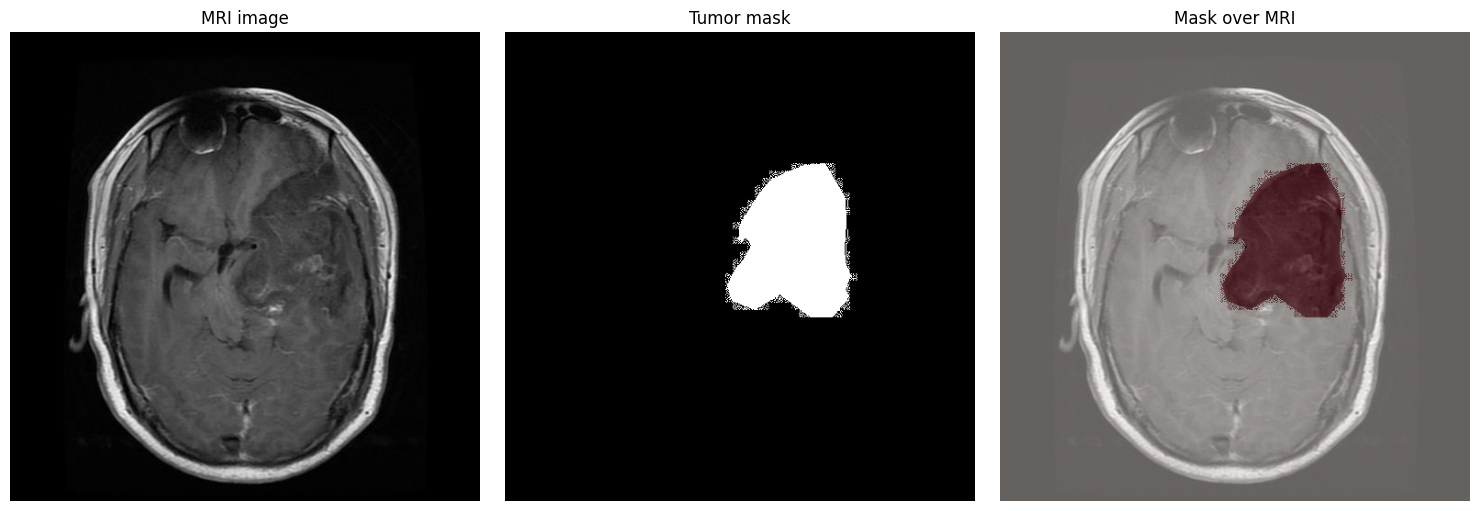

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image


image_path, mask_path = official_train_pairs[0]

raw_image = np.array(
    Image.open(image_path).convert("L")
)

raw_mask = np.array(
    Image.open(mask_path).convert("L")
)

binary_mask = raw_mask > 0

print("Image shape:", raw_image.shape)
print("Mask shape: ", raw_mask.shape)
print("Image pixel range:", raw_image.min(), "to", raw_image.max())
print("Mask values:", np.unique(raw_mask))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_image, cmap="gray")
axes[0].set_title("MRI image")

axes[1].imshow(binary_mask, cmap="gray")
axes[1].set_title("Tumor mask")

axes[2].imshow(raw_image, cmap="gray")
axes[2].imshow(binary_mask, cmap="Reds", alpha=0.4)
axes[2].set_title("Mask over MRI")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

Binary mask values: [False  True]
Tumor pixel count: 16345


<function matplotlib.pyplot.show(close=None, block=None)>

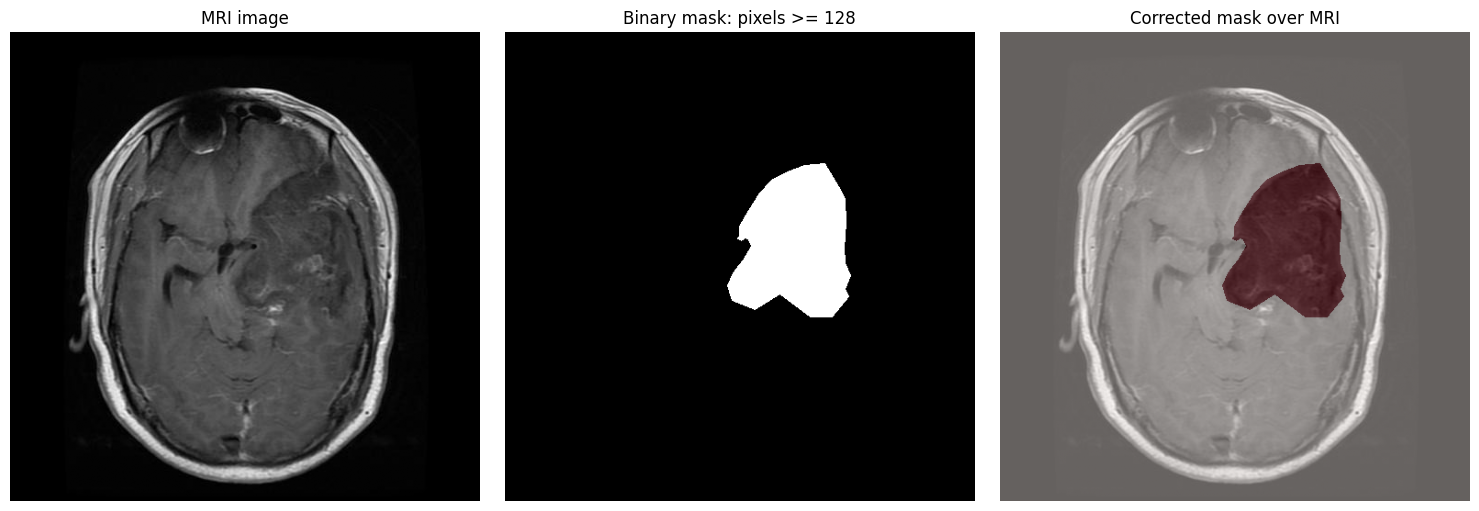

In [14]:
binary_mask = raw_mask >= 128

print("Binary mask values:", np.unique(binary_mask))
print("Tumor pixel count:", binary_mask.sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_image, cmap="gray")
axes[0].set_title("MRI image")

axes[1].imshow(binary_mask, cmap="gray")
axes[1].set_title("Binary mask: pixels >= 128")

axes[2].imshow(raw_image, cmap="gray")
axes[2].imshow(
    binary_mask,
    cmap="Reds",
    alpha=0.4,
)
axes[2].set_title("Corrected mask over MRI")

for axis in axes:
  axis.axis("off")

plt.tight_layout()
plt.show

In [15]:
import random

SEED = 42

shuffled_pairs = official_train_pairs.copy()

random_generator = random.Random(SEED)
random_generator.shuffle(shuffled_pairs)

validation_count = int(
    0.20 * len(shuffled_pairs)
)

val_pairs = shuffled_pairs[:validation_count]
train_pairs = shuffled_pairs[validation_count:]

print("Training pairs:  ", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Test pairs:      ", len(test_pairs))

assert len(train_pairs) == 3147
assert len(val_pairs) == 786
assert len(test_pairs) == 860

print("\nData split completed successfully.")

Training pairs:   3147
Validation pairs: 786
Test pairs:       860

Data split completed successfully.


In [16]:
import math

from PIL import Image
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from tqdm.notebook import tqdm


IMAGE_SIZE = (256, 256)


def calculate_mean_std(pairs):
    pixel_sum = 0.0
    squared_pixel_sum = 0.0
    pixel_count = 0

    for image_path, _ in tqdm(
        pairs,
        desc="Calculating pixel statistics",
    ):
        image = Image.open(image_path).convert("L")

        image = TF.resize(
            image,
            IMAGE_SIZE,
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        image_tensor = TF.to_tensor(image).double()

        pixel_sum += image_tensor.sum().item()
        squared_pixel_sum += (
            image_tensor ** 2
        ).sum().item()
        pixel_count += image_tensor.numel()

    mean = pixel_sum / pixel_count

    variance = (
        squared_pixel_sum / pixel_count
        - mean ** 2
    )

    std = math.sqrt(max(variance, 1e-8))

    return mean, std


TRAIN_MEAN, TRAIN_STD = calculate_mean_std(
    train_pairs
)

print("\nTraining mean:", TRAIN_MEAN)
print("Training standard deviation:", TRAIN_STD)

assert 0 <= TRAIN_MEAN <= 1
assert TRAIN_STD > 0

print("Pixel statistics calculated successfully.")

Calculating pixel statistics:   0%|          | 0/3147 [00:00<?, ?it/s]


Training mean: 0.1667456691437646
Training standard deviation: 0.17331759220110424
Pixel statistics calculated successfully.


In [17]:
from torch.utils.data import Dataset



class BrainTumorDataset(Dataset):
  def __init__(self, pairs, mean, std):
    self.pairs = pairs
    self.mean = mean
    self.std = std

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, index):
    image_path, mask_path = self.pairs[index]

    image = Image.open(image_path).convert("L")
    mask = Image.open(mask_path).convert("L")

    # Resize the MRI smoothly
    image = TF.resize(
        image,
        IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    # Preserve mask labels during resizing
    mask = TF.resize(
        mask,
        IMAGE_SIZE,
        interpolation=InterpolationMode.NEAREST,
    )

    # Convert MRI to values between 0 and 1
    image = TF.to_tensor(image)

    # Standardize MRI pixels
    image = (
        image - self.mean
    ) / self.std

    # Convert the mask and apply the correct threshold
    mask = TF.pil_to_tensor(mask)
    mask = (mask >= 128).float()

    return image, mask



train_dataset = BrainTumorDataset(
    train_pairs,
    TRAIN_MEAN,
    TRAIN_STD,
)

val_dataset = BrainTumorDataset(
    val_pairs,
    TRAIN_MEAN,
    TRAIN_STD,
)

test_dataset = BrainTumorDataset(
    test_pairs,
    TRAIN_MEAN,
    TRAIN_STD,
)


sample_image, sample_mask = train_dataset[0]

print("Training samples:  ", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:      ", len(test_dataset))

print("\nSample image shape:", sample_image.shape)
print("Sample mask shape:  ", sample_mask.shape)
print("Sample image type:  ", sample_image.dtype)
print("Sample mask type:   ", sample_mask.dtype)
print("Mask values:        ", torch.unique(sample_mask))

Training samples:   3147
Validation samples: 786
Test samples:       860

Sample image shape: torch.Size([1, 256, 256])
Sample mask shape:   torch.Size([1, 256, 256])
Sample image type:   torch.float32
Sample mask type:    torch.float32
Mask values:         tensor([0., 1.])


In [18]:
from torch.utils.data import DataLoader


BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

batch_images, batch_masks = next(
    iter(train_loader)
)

print("Batch image shape:", batch_images.shape)
print("Batch mask shape: ", batch_masks.shape)
print("Batch mask values:", torch.unique(batch_masks))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch image shape: torch.Size([8, 1, 256, 256])
Batch mask shape:  torch.Size([8, 1, 256, 256])
Batch mask values: tensor([0., 1.])


In [19]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", DEVICE)

if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

Training device: cpu


In [20]:
import torch.nn as nn


class DoubleConvolution(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.layers(x)


class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder1 = DoubleConvolution(1, 16)
        self.encoder2 = DoubleConvolution(16, 32)
        self.pool = nn.MaxPool2d(kernel_size=2)

        # Bottleneck
        self.bottleneck = DoubleConvolution(32, 64)

        # Decoder
        self.up2 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2,
        )

        self.decoder2 = DoubleConvolution(64, 32)

        self.up1 = nn.ConvTranspose2d(
            32,
            16,
            kernel_size=2,
            stride=2,
        )

        self.decoder1 = DoubleConvolution(32, 16)

        # One tumor logit for every pixel.
        self.output_layer = nn.Conv2d(
            16,
            1,
            kernel_size=1,
        )

    def forward(self, x):
        encoder1_output = self.encoder1(x)

        encoder2_output = self.encoder2(
            self.pool(encoder1_output)
        )

        bottleneck_output = self.bottleneck(
            self.pool(encoder2_output)
        )

        decoder2_output = self.up2(
            bottleneck_output
        )

        decoder2_output = torch.cat(
            [decoder2_output, encoder2_output],
            dim=1,
        )

        decoder2_output = self.decoder2(
            decoder2_output
        )

        decoder1_output = self.up1(
            decoder2_output
        )

        decoder1_output = torch.cat(
            [decoder1_output, encoder1_output],
            dim=1,
        )

        decoder1_output = self.decoder1(
            decoder1_output
        )

        return self.output_layer(
            decoder1_output
        )


model = SmallUNet().to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Model parameters: {parameter_count:,}")
print("Model device:", next(model.parameters()).device)

Model parameters: 117,393
Model device: cpu


In [21]:
test_batch = batch_images[:2].to(DEVICE)

with torch.no_grad():
  test_output = model(test_batch)

print("Model input shape: ", test_batch.shape)
print("Model output shape:", test_output.shape)

assert test_output.shape == (
    2,
    1,
    256,
    256,
)

print("Model output shape is correct.")

Model input shape:  torch.Size([2, 1, 256, 256])
Model output shape: torch.Size([2, 1, 256, 256])
Model output shape is correct.


In [22]:
BCE_LOSS = nn.BCEWithLogitsLoss()


def segmentation_loss(logits, targets):
  # pixel by pixel binary cross entropy
  bce = BCE_LOSS(logits, targets)

  # soft dice loss
  probabilities = torch.sigmoid(logits)
  dimensions = (1, 2, 3)
  epsilon = 1e-6

  intersection = (
      probabilities * targets
  ).sum(dimensions)

  denominator = (
      probabilities.sum(dimensions)
      + targets.sum(dimensions)
  )

  soft_dice = (
      2 * intersection + epsilon
  ) / (
      denominator + epsilon
  )

  dice_loss = 1 - soft_dice.mean()

  return 0.5 * bce + 0.5 * dice_loss


def calculate_scores(logits, targets):
  predictions = (
      torch.sigmoid(logits) >= 0.5
  ).float()

  dimensions = (1, 2, 3)
  epsilon = 1e-6

  intersection = (
      predictions * targets
  ).sum(dimensions)

  predicted_total = predictions.sum(dimensions)
  target_total = targets.sum(dimensions)

  union = (
      predicted_total
      + target_total
      - intersection
  )

  dice = (
      2 * intersection + epsilon
  ) / (
      predicted_total + target_total + epsilon
  )

  iou = (
      intersection + epsilon
  ) / (
      union + epsilon
  )

  return dice, iou


def train_one_epoch(model, loader, optimizer):
  model.train()

  total_loss = 0.0
  sample_count = 0

  progress = tqdm(
      loader,
      desc="Training",
      leave=False,
  )

  for images, masks in progress:
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()

    logits = model(images)
    loss = segmentation_loss(logits, masks)

    loss.backward()
    optimizer.step()

    batch_size = images.size(0)

    total_loss += loss.item() * batch_size
    sample_count += batch_size
    progress.set_postfix(
        loss=f"{loss.item():.4f}"
    )

  return total_loss / sample_count


@torch.no_grad()
def evaluate(model, loader):
  model.eval()

  total_loss = 0.0
  total_dice = 0.0
  total_iou = 0.0
  sample_count = 0

  for images, masks in loader:
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    logits = model(images)
    loss = segmentation_loss(logits, masks)

    dice, iou = calculate_scores(
        logits,
        masks,
    )

    batch_size = images.size(0)

    total_loss += loss.item() * batch_size
    total_dice += dice.sum().item()
    total_iou += iou.sum().item()
    sample_count += batch_size

  return(
      total_loss / sample_count,
      total_dice / sample_count,
      total_iou / sample_count,
  )

print("Loss and metric functions are ready.")



Loss and metric functions are ready.


In [ ]:
import time


LEARNING_RATE = 0.001
NUMBER_OF_EPOCHS = 10

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

BEST_MODEL_PATH = (
    OUTPUT_DIR / "best_small_unet.pt"
)

best_validation_dice = -1.0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
}

start_time = time.time()

for epoch in range(1, NUMBER_OF_EPOCHS + 1):
  training_loss = train_one_epoch(
      model,
      train_loader,
      optimizer,
  )

  validation_loss, validation_dice, validation_iou = (
      evaluate(model, val_loader)
  )

  history["train_loss"].append(training_loss)
  history["val_loss"].append(validation_loss)
  history["val_dice"].append(validation_dice)
  history["val_iou"].append(validation_iou)

  print(
      f"Epoch {epoch:02d}/{NUMBER_OF_EPOCHS} | "
      f"train loss: {training_loss:.4f} | "
      f"val loss: {validation_loss:.4f} | "
      f"Dice: {validation_dice:.4f} | "
      f"IoU: {validation_iou:.4f}"
  )

  if validation_dice > best_validation_dice:
    best_validation_dice = validation_dice

    torch.save(
        model.state_dict(),
        BEST_MODEL_PATH,
    )

    print("Saved new best model.")

elapsed_minutes = (
    time.time() - start_time
) / 60

print("\nTraining complete.")
print(f"Time: {elapsed_minutes:.1f} minutes")
print(f"Best validation Dice: {best_validation_dice:.4f}")
print("Model saved to:", BEST_MODEL_PATH)

Training:   0%|          | 0/394 [00:00<?, ?it/s]

In [ ]:
saved_weights = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True,
)

model.load_state_dict(saved_weights)

test_loss, test_dice, test_iou = evaluate(
    model,
    test_loader
)

print("FINAL TEST RESULTS")
print("==================")
print(f"Test loss: {test_loss:.4f}")
print(f"Mean Dice: {test_dice:.4f}")
print(f"Mean IoU:  {test_iou:.4f}")


RESULTS_PATH = OUTPUT_DIR / "test_results.txt"

results_text = f"""
Brain Tumor Segmentation Results
================================

Training Images: {len(train_dataset)}
Validation images: {len(val_dataset)}
Test images: {len(test_dataset)}

Image size: {IMAGE_SIZE}
Batch size: {BATCH_SIZE}
Epochs: {NUMBER_OF_EPOCHS}
Learning rate: {LEARNING_RATE}

Best Validation Dice: {best_validation_dice:.4f}

Test loss: {test_loss:.4f}
Mean test Dice: {test_dice:.4f}
Mean test IoU: {test_iou:.4f}
"""


RESULTS_PATH.write_text(results_text)

print("\nResults saved to:")
print(RESULTS_PATH)

In [ ]:
# select 1 test MRI
example_index = 0

standardized_image, true_mask = test_dataset[
    example_index
]

model_input = (
    standardized_image
    .unsqueeze(0)
    .to(DEVICE)
)

model.eval()

with torch.no_grad():
  logits = model(model_input)

  probability_mask = torch.sigmoid(
      logits
  )[0, 0].cpu()

predicted_mask = probability_mask >= 0.5
true_binary_mask = true_mask[0] >= 0.5

# undo image standardization for diplay purposes
display_image = (
    standardized_image[0] * TRAIN_STD
    + TRAIN_MEAN
)

display_image = display_image.clamp(0, 1)

# calculate this examples scores
intersection = (
    predicted_mask & true_binary_mask
).sum().item()

predicted_total = predicted_mask.sum().item()
true_total = true_binary_mask.sum().item()

union = (
    predicted_mask | true_binary_mask
).sum().item()

example_dice = (
    2 * intersection
    / (predicted_total + true_total + 1e-6)
)

example_iou = (
    intersection
    / (union + 1e-6)
)

print(f"Example Dice: {example_dice:.4f}")
print(f"Example IoU:  {example_iou:.4f}")


# create the prediction figure
fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5),
)

axes[0].imshow(
    display_image,
    cmap="gray",
)
axes[0].set_title("MRI input")

axes[1].imshow(
    true_binary_mask,
    cmap="gray",
)
axes[1].set_title("True tumor mask")

axes[2].imshow(
    probability_mask,
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[2].set_title("Tumor probability")

axes[3].imshow(
    display_image,
    cmap="gray",
)
axes[3].imshow(
    predicted_mask,
    cmap="Reds",
    alpha=0.4,
)
axes[3].set_title(
    f"Prediction\nDice = {example_dice:.3f}"
)

for axis in axes:
  axis.axis("off")

  plt.tight_layout()

  PREDICTION_PATH = (
      OUTPUT_DIR / "example_prediction.png"
  )

  plt.savefig(
      PREDICTION_PATH,
      dpi=180,
      bbox_inches="tight",
  )

  plt.show()


  # create the training history figure
  epochs = range (
      1,
      len(history["train_loss"]) +1,
  )

  fig, axes = plt.subplots(
      1,
      2,
      figsize=(14, 5),
  )

  axes[0].plot(
      epochs,
      history["train_loss"],
      marker="o",
      label="Training loss",
  )

  axes[0].plot(
      epochs,
      history["val_loss"],
      marker="o",
      label="Validation loss",
  )

  axes[0].set_title("Loss during training")
  axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Loss")
  axes[0].legend()
  axes[0].grid(alpha=0.3)

  axes[1].plot(
      epochs,
      history["val_dice"],
      marker="o",
      label="Validation Dice",
  )

  axes[1].plot(
      epochs,
      history["val_iou"],
      marker="o",
      label="Validation IoU",
  )

  axes[1].set_title("Validation performance")
  axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Score")
  axes[1].set_ylim(0, 1)
  axes[1].legend()
  axes[1].grid(alpha=0.3)

  plt.tight_layout()

  HISTORY_PATH = (
      OUTPUT_DIR / "training_history.png"
  )

  plt.savefig(
      HISTORY_PATH,
      dpi=180,
      bbox_inches="tight",
  )

  plt.show()

  print("\nSaved prediction to:")
  print(PREDICTION_PATH)

  print("\nSaved training graphs to:")
  print(HISTORY_PATH)

  print("\nPROJECT COMPLETE.")
